## Reconhecimento de Letras Gregas com CNN e Visual Transformer
## Trabalho Final de Inteligência Artificial - UNIFESP
## Profa. Dra. Lilian Berton

## Alunos:
## Larissa Adelino Ângelo Rosa - 163.879
## Pedro Ernesto Duarte Pilchowski - RA: 156.331

Monta o Google Drive para acesso aos arquivos processados

In [ ]:
# AJUSTAR PARA O SEU DRIVE
from google.colab import drive
import os, sys
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/Trabalho IA'
sys.path.append("/content/drive/MyDrive/Colab Notebooks/Trabalho IA/src")

import letra_utils

Mounted at /content/drive


# Preparando dataset Transformer

## Extrai as letras do dataset no formato 224x224 pixels (formato de entrada do ViT)

In [ ]:
letra_utils.extrai_letras(224, "transformer")


Processando diretório: temp/Bessarion/processing/copias/bom...

Processando diretório: temp/Bessarion/processing/copias/ok...

EXTRAÇÃO CONCLUÍDA E ORGANIZADA POR PASTAS!
Arquivos XML processados: 15
Total de caracteres extraídos: 1490
Pasta de destino: /content/drive/MyDrive/Colab Notebooks/Trabalho IA/data/training_data/letras_extraidas_transformer
----------------------------------------
Resumo por caractere (Top 15 mais frequentes):
  Letra 'Α': 91 amostras
  Letra 'Σ': 67 amostras
  Letra 'Ν': 66 amostras
  Letra 'Ι': 62 amostras
  Letra 'ΟΥ': 59 amostras
  Letra 'Ο': 57 amostras
  Letra 'Ε': 56 amostras
  Letra 'Τ': 56 amostras
  Letra 'Κ': 55 amostras
  Letra 'Ω': 52 amostras
  Letra 'Ρ': 44 amostras
  Letra 'ΑΝ': 43 amostras
  Letra 'Π': 41 amostras
  Letra 'Η': 38 amostras
  Letra 'Μ': 35 amostras
  ... e mais 143 classes de caracteres.


## Remove letras com apenas uma ocorrência

In [ ]:
letra_utils.filtrar_letras_raras(2, "transformer")

Iniciando filtragem de categorias com menos de 2 elementos...
  -> Movido: Categoria 'ΠΑΝ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΡΟΥ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΠΤ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΗΟΥ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΡΧ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΒΑ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΤΣ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΗΜΩΝ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΗΠ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΓΚ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΑΙ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΑΤΟΥ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΑΠΑΗΣ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΝΤ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΜΗΤΡΟ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΑΚΤ' (1 itens) para rejeitadas.
  -> Movido: Categoria 'ΥΡΙ' (1 itens) para 

## Realiza Data Augmentation Offline

In [ ]:
letra_utils.data_augmentation(100, "transformer")

Iniciando o Data Augmentation Offline nas classes raras (Meta: 100 amostras)...

Classe 'Σ': Possui 67 amostras. Gerando +33...
Classe 'Ε': Possui 56 amostras. Gerando +44...
Classe 'Η': Possui 38 amostras. Gerando +62...
Classe 'Ο': Possui 57 amostras. Gerando +43...
Classe 'Θ': Possui 23 amostras. Gerando +77...
Classe 'ΕΙ': Possui 14 amostras. Gerando +86...
Classe 'Κ': Possui 55 amostras. Gerando +45...
Classe 'Π': Possui 41 amostras. Gerando +59...
Classe 'ΑΝ': Possui 43 amostras. Gerando +57...
Classe 'Ι': Possui 62 amostras. Gerando +38...
Classe 'Ρ': Possui 44 amostras. Gerando +56...
Classe 'Ν': Possui 66 amostras. Gerando +34...
Classe 'Α': Possui 91 amostras. Gerando +9...
Classe 'Τ': Possui 56 amostras. Gerando +44...
Classe 'ΟΥ': Possui 59 amostras. Gerando +41...
Classe 'Γ': Possui 23 amostras. Gerando +77...
Classe 'Μ': Possui 35 amostras. Gerando +65...
Classe 'Ω': Possui 52 amostras. Gerando +48...
Classe 'Λ': Possui 24 amostras. Gerando +76...
Classe 'Υ': Possui 28 am

# Configurando o modelo Transformer com PyTorch

## Carregando o modelo
Configuramos a normalização e a aplicamos ao dataset. Separamos 80% dos dados para treinamento e 20% para validação. Utilizamos `shuffle=True` para que os dados sejam entregues de forma mais espalhada na etapa de treinamento.

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Configuração de dispositivo (GPU se disponível, senão CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando o dispositivo: {device}")

DATA_DIR = os.path.join(BASE_PATH, "data/training_data/letras_extraidas_transformer")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# No PyTorch, a normalização padrão do ViT (média e desvio padrão do ImageNet)
# substitui o escalonamento manual [-1, 1] do Keras.
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    # Normalização padrão que o ViT da Hugging Face espera:
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Carrega o dataset completo
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
num_classes = len(full_dataset.classes)

# Divisão de Treino e Validação (80% / 20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Seed manual para reprodutibilidade
torch.manual_seed(123)
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Criação dos DataLoaders (equivalente ao image_dataset_from_directory)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Usando o dispositivo: cpu


## Construindo o modelo

In [ ]:
import torch.nn as nn
from transformers import ViTModel

class ViTClassifier(nn.Module):
    def __init__(self, num_classes):
        super(ViTClassifier, self).__init__()
        # Carrega o ViT pré-treinado
        self.vit_base = ViTModel.from_pretrained('google/vit-base-patch16-224')

        # Congela o Transformer core inicialmente (Equivalente ao trainable = False)
        for param in self.vit_base.parameters():
            param.requires_grad = False

        # Cabeça de classificação customizada
        # O ViT-base tem uma dimensão oculta (hidden_size) de 768
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes) # Sem Softmax aqui, pois o CrossEntropyLoss já aplica internamente
        )

    def forward(self, pixel_values):
        # Passa pelo bloco do Transformer
        outputs = self.vit_base(pixel_values=pixel_values)

        # No PyTorch, o Hugging Face expõe o Class Token diretamente em 'pooler_output'
        # ou você pode pegar outputs.last_hidden_state[:, 0, :]
        cls_token = outputs.pooler_output

        # Passa pela cabeça customizada
        logits = self.classifier(cls_token)
        return logits

model = ViTClassifier(num_classes=num_classes).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Treinamento

In [ ]:
# Filtra para otimizar apenas os parâmetros que não estão congelados (a cabeça)
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# Otimizador e Função de Perda
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 10

# Listas para armazenar o histórico de treinamento
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Iniciando o treinamento (Warm-up da cabeça de classificação)...")
for epoch in range(epochs):
    # --- FASE DE TREINO ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Criando a barra de progresso visual para o treino
    train_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs} [Treino]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Atualiza a barra com o loss atual do batch
        train_bar.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # Adiciona ao histórico
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Época {epoch+1}/{epochs} [Validação]", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    # Adiciona ao histórico
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Fim da Época {epoch+1} -> "
          f"Loss Treino: {epoch_train_loss:.4f} | Acc Treino: {epoch_train_acc:.4f} | "
          f"Loss Val: {epoch_val_loss:.4f} | Acc Val: {epoch_val_acc:.4f}")

# Salva o histórico completo
history = {
    'train_loss': train_losses,
    'train_acc': train_accs,
    'val_loss': val_losses,
    'val_acc': val_accs
}

print("Treinamento concluído!")

Iniciando o treinamento (Warm-up da cabeça de classificação)...


Época 1/10 [Treino]:   0%|          | 0/225 [00:00<?, ?it/s]

Época 1/10 [Validação]:   0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
import os
import torch

# Define the directory for saving the model and history
MODEL_SAVE_DIR = os.path.join(BASE_PATH, "data/model/transformer")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Save the model state dictionary
model_path = os.path.join(MODEL_SAVE_DIR, "vit_classifier_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Modelo salvo em: {model_path}")

# Save the training history
history_path = os.path.join(MODEL_SAVE_DIR, "training_history.pth")
torch.save(history, history_path)
print(f"Histórico de treinamento salvo em: {history_path}")

Histórico de treinamento carregado com sucesso:
  train_loss: [3.7526279201306183, 3.5307778052138965, 3.242154656002408, 2.9410962637810947, 2.6685195514380053]...
  train_acc: [0.06724090025006946, 0.2028341205890525, 0.3134203945540428, 0.3848291191997777, 0.441511530980828]...
  val_loss: [3.665476917690701, 3.4180440711975097, 3.13332631111145, 2.858980900446574, 2.622447027630276]...
  val_acc: [0.18666666666666668, 0.32666666666666666, 0.3877777777777778, 0.45, 0.4822222222222222]...


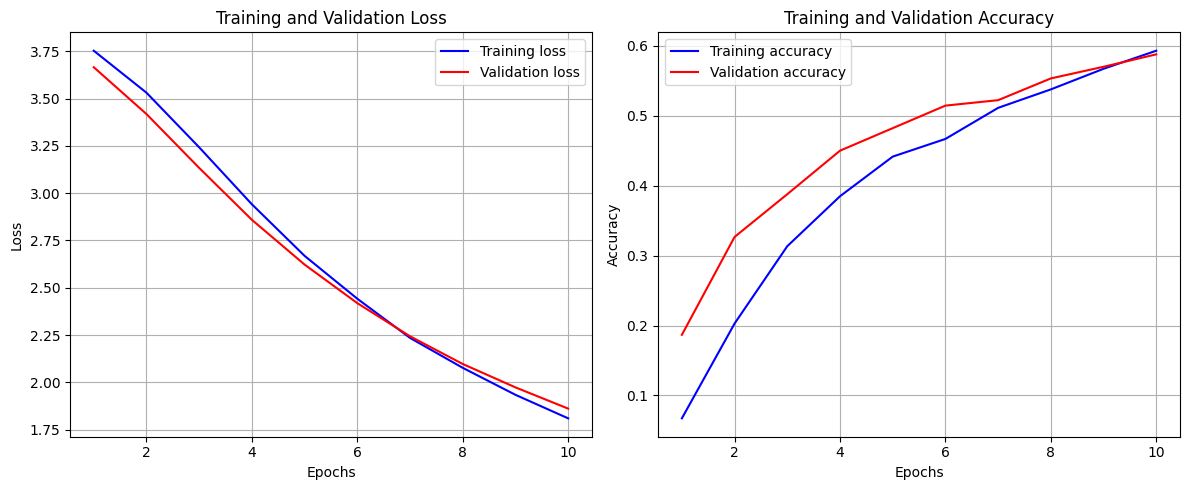

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

# Define the directory where the history was saved
MODEL_SAVE_DIR = os.path.join(BASE_PATH, "data", "model", "transformer")
history_path = os.path.join(MODEL_SAVE_DIR, "historico-transformer-2.pth")

# Check if the history file exists and load it
if os.path.exists(history_path):
    loaded_history = torch.load(history_path)
    print("Histórico de treinamento carregado com sucesso:")
    for key, value in loaded_history.items():
        print(f"  {key}: {value[:5]}...") # Displaying first 5 elements for brevity

    # Plotting the training history
    epochs = range(1, len(loaded_history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plotting Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loaded_history['train_loss'], 'b', label='Training loss')
    plt.plot(epochs, loaded_history['val_loss'], 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plotting Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loaded_history['train_acc'], 'b', label='Training accuracy')
    plt.plot(epochs, loaded_history['val_acc'], 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: Arquivo de histórico não encontrado em: {history_path}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo carregado com sucesso de: /content/drive/MyDrive/Colab Notebooks/Trabalho IA/data/model/transformer/transformer-1.pth


<Figure size 9000x9000 with 0 Axes>

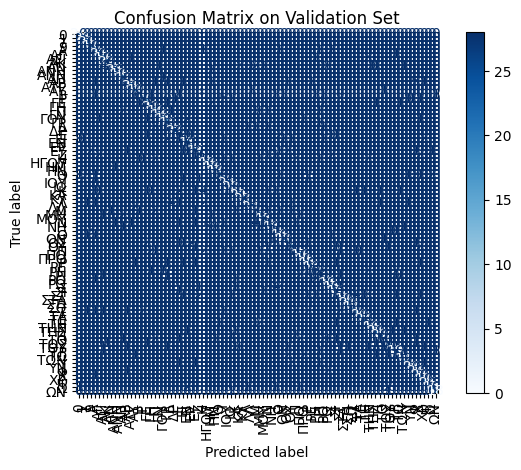

In [ ]:
import os
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Define the directory where the model was saved
MODEL_SAVE_DIR = os.path.join(BASE_PATH, "data", "model", "transformer")
model_load_path = os.path.join(MODEL_SAVE_DIR, "transformer-1.pth") # Use the actual model name saved previously

# Instantiate the model architecture (assuming ViTClassifier and num_classes are defined in previous cells)
# Make sure `num_classes` is accessible, it should be from cell `dWwV5AB9Qirs`
if 'num_classes' not in globals():
    print("Error: `num_classes` not found. Please ensure previous cells defining the dataset and model are run.")
    # Fallback or raise error, adjust as needed
    # For this example, let's assume it's defined.

loaded_model = ViTClassifier(num_classes=num_classes).to(device)

# Load the saved state dictionary
if os.path.exists(model_load_path):
    loaded_model.load_state_dict(torch.load(model_load_path, map_location=device))
    loaded_model.eval() # Set model to evaluation mode
    print(f"Modelo carregado com sucesso de: {model_load_path}")

    # Collect all true labels and predictions from the validation set
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = loaded_model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Get class names for display (assuming full_dataset.classes is available)
    if 'full_dataset' in globals():
        class_names = full_dataset.classes
    else:
        class_names = [str(i) for i in range(num_classes)] # Fallback if not available

    # Plot the confusion matrix
    plt.figure(figsize=(len(class_names), len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix on Validation Set')
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: Arquivo do modelo não encontrado em: {model_load_path}")

# Testando o modelo

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import cv2
from PIL import Image

# ==========================================
# 1. Configurações para o Dataset de Teste
# ==========================================
TEST_DATA_DIR = os.path.join(BASE_PATH, "letras_teste_processadas")

# Certifique-se de que a pasta de teste existe
if not os.path.exists(TEST_DATA_DIR):
    print(f"Aviso: Pasta de teste '{TEST_DATA_DIR}' não encontrada. Por favor, execute a célula de pré-processamento de imagens primeiro.")
else:
    # Cria um dataset customizado para as imagens de teste
    # Como não temos subpastas para classes, precisamos adaptar.
    # Usaremos ImageFolder e trataremos cada imagem como uma 'classe' única inicialmente
    # ou iterar sobre elas manualmente.

    # Para simplicidade, vamos criar um dataset de imagens sem rótulos e mapear os nomes dos arquivos.
    class InferenceDataset(torch.utils.data.Dataset):
        def __init__(self, root_dir, transform=None):
            self.root_dir = root_dir
            self.transform = transform
            self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.tiff', '.png', '.jpg', '.jpeg'))]
            # Mapeia nomes de arquivo para índices para manter a ordem
            self.file_names = {i: self.image_files[i] for i in range(len(self.image_files))}

        def __len__(self):
            return len(self.image_files)

        def __getitem__(self, idx):
            img_name = self.image_files[idx]
            img_path = os.path.join(self.root_dir, img_name)
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # OpenCV reads BGR, PyTorch expects RGB

            # Converte o array numpy para uma imagem PIL antes de aplicar as transformações
            image_pil = Image.fromarray(image)

            # Aplica as mesmas transformações que as fo treino
            if self.transform:
                image = self.transform(image_pil)

            return image, img_name

    # Crie o dataset e o DataLoader para as imagens de teste
    inference_dataset = InferenceDataset(root_dir=TEST_DATA_DIR, transform=transform)
    inference_loader = DataLoader(inference_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Obtém o mapeamento de classes do dataset de treino (necessário para interpretar as previsões)
    if 'full_dataset' in locals() or 'full_dataset' in globals():
        class_to_idx = full_dataset.class_to_idx
        idx_to_class = {v: k for k, v in class_to_idx.items()}
        print(f"Mapeamento de classes: {idx_to_class}")
    else:
        print("Aviso: `full_dataset` não encontrado. Não será possível mapear IDs de classe para nomes. As previsões serão exibidas como números.")
        idx_to_class = None

    # ==========================================
    # 2. Realizar Inferência
    # ==========================================
    model.eval() # Coloca o modelo em modo de avaliação

    print("\nIniciando inferência nas imagens de teste...")
    predictions = []

    with torch.no_grad(): # Desativa o cálculo de gradientes
        for images, filenames in inference_loader:
            images = images.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted_indices = torch.max(probabilities, 1)

            for i, filename in enumerate(filenames):
                predicted_class_id = predicted_indices[i].item()
                predicted_label = idx_to_class[predicted_class_id] if idx_to_class else predicted_class_id
                predictions.append((filename, predicted_label))

    # ==========================================
    # 3. Exibir Resultados
    # ==========================================
    print("\n" + "="*40)
    print("RESULTADOS DA INFERÊNCIA")
    print("="*40)
    if predictions:
        for filename, label in predictions:
            print(f"Imagem: {filename} -> Classe Predita: {label}")
    else:
        print("Nenhuma imagem processada ou resultados gerados.")
    print("-" * 40)

Mapeamento de classes: {0: '0', 1: '1', 2: '7', 3: '9', 4: 'Α', 5: 'ΑΓ', 6: 'ΑΓΙ', 7: 'ΑΚ', 8: 'ΑΝ', 9: 'ΑΝΗ', 10: 'ΑΝΝ', 11: 'ΑΠ', 12: 'ΑΡ', 13: 'ΑΤΡ', 14: 'ΑΥ', 15: 'Β', 16: 'Γ', 17: 'ΓΕ', 18: 'ΓΗ', 19: 'ΓΙ', 20: 'ΓΝ', 21: 'ΓΟΥ', 22: 'ΓΡ', 23: 'Δ', 24: 'ΔΡ', 25: 'Ε', 26: 'ΕΙ', 27: 'ΕΝ', 28: 'ΕΡ', 29: 'ΕΥ', 30: 'Ζ', 31: 'Η', 32: 'ΗΓΟΥ', 33: 'ΗΜ', 34: 'ΗΝ', 35: 'Θ', 36: 'Ι', 37: 'ΙΟΥ', 38: 'ΙΩ', 39: 'Κ', 40: 'ΚΑ', 41: 'ΚΥ', 42: 'Λ', 43: 'ΛΛ', 44: 'Μ', 45: 'ΜΗ', 46: 'ΜΟΥ', 47: 'Ν', 48: 'ΝΗ', 49: 'Ξ', 50: 'Ο', 51: 'ΟΝ', 52: 'ΟΣ', 53: 'ΟΥ', 54: 'Π', 55: 'ΠΟ', 56: 'ΠΡΟ', 57: 'Ρ', 58: 'ΡΕ', 59: 'ΡΗ', 60: 'ΡΙ', 61: 'ΡΟ', 62: 'ΡΩ', 63: 'Σ', 64: 'ΣΙ', 65: 'ΣΤ', 66: 'ΣΤΑ', 67: 'ΣΤΙ', 68: 'ΣΩ', 69: 'Τ', 70: 'ΤΑ', 71: 'ΤΕ', 72: 'ΤΗ', 73: 'ΤΗΝ', 74: 'ΤΗΣ', 75: 'ΤΙ', 76: 'ΤΟ', 77: 'ΤΟΣ', 78: 'ΤΟΥ', 79: 'ΤΡ', 80: 'ΤΩ', 81: 'ΤΩΝ', 82: 'Υ', 83: 'ΥΝ', 84: 'Φ', 85: 'Χ', 86: 'ΧΡ', 87: 'Ψ', 88: 'Ω', 89: 'ΩΝ'}

Iniciando inferência nas imagens de teste...

RESULTADOS DA INFERÊNCIA
Imagem: teste2.png -> Cla